# 🌿 Plant Disease Detection - EfficientNetB0 (Smart Zip Dataset Resolution)

This notebook provides an end-to-end transfer learning pipeline for plant disease classification. It features **smart dataset resolution** to automatically detect, unzip, and locate image datasets uploaded as `.zip` files to Google Drive or local workspace.

### 🚀 Key Features:
- ⚡ **GPU Hardware Acceleration**: Auto-detects T4/V100/A100 GPU (`nvidia-smi` & TensorFlow GPU device allocation)
- 🔍 **Smart Dataset & Zip Locator**: Automatically searches for `.zip` files on Google Drive, extracts them, and recursively locates dataset root folders (handling nested folders, `__MACOSX`, etc.)
- 🔄 **Two-Stage Transfer Learning**:
  - **Phase 1**: Feature Extraction (Base EfficientNetB0 frozen)
  - **Phase 2**: Fine-Tuning top 40 backbone layers with low learning rate (`1e-5`)
- 📊 **Evaluation Metrics & Charts**: Accuracy/Loss history curves, Classification Report, & Confusion Matrix heatmap
- 📷 **Interactive Single-Image Prediction**: Test custom uploaded leaf images or dataset sample images
- 💾 **Google Drive Artifact Export**: Backs up trained `.keras` model, `class_names.json`, and charts back to Drive

## ⚡ Step 1: Check GPU Acceleration & Environment Setup
Verify GPU hardware allocation (T4 / V100 / A100) and set random seeds for reproducibility.

In [1]:
import tensorflow as tf
import os
import sys
import json
import time
import zipfile
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

# Check GPU Availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Available! Found {len(gpus)} GPU device(s):")
    for gpu in gpus:
        print(f"  - {gpu.name}")
    print("\n--- GPU Info ---")
    try:
        !nvidia-smi
    except Exception as e:
        print("nvidia-smi check skipped:", e)
else:
    print("ℹ️ Note: Running on CPU. In Colab, go to Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU.")

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1788088835.766583     789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788088836.509888     789 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788088840.560223     789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow Version: 2.21.0
✅ GPU Available! Found 1 GPU device(s):
  - /physical_device:GPU:0

--- GPU Info ---
Sun Aug 30 11:20:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050        On  |   00000000:01:00.0 Off |                  N/A |
| N/A   48C    P0              6W /   65W |       0MiB /   4096MiB |      0%      Default |
|                           

## 🔄 Step 2: Data Loading & Preprocessing Pipeline
Loads image dataset with batching, auto train/val splitting, and GPU prefetching.

In [23]:
import os

IMG_SIZE = 224
BATCH_SIZE = 32

DATA_DIR = "../../PlantVillage_28"
OUTPUT_DIR = "../models"

os.makedirs(OUTPUT_DIR, exist_ok=True)

train_subdir = os.path.join(DATA_DIR, "train")
val_subdir = os.path.join(DATA_DIR, "val")

if os.path.exists(train_subdir) and os.path.exists(val_subdir):

    print(f"[INFO] Loading dataset from explicit train and val subfolders in '{DATA_DIR}'")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_subdir,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=42
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_subdir,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names

else:

    print(f"[INFO] Applying 80/20 train/val split on directory '{DATA_DIR}'")

    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="training",
        seed=42,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        validation_split=0.2,
        subset="validation",
        seed=42,
        labels="inferred",
        label_mode="int",
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names

print(f"[INFO] Found {len(class_names)} classes.")
print(f"[INFO] Classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)




[INFO] Loading dataset from explicit train and val subfolders in '../../PlantVillage_28'
Found 30835 files belonging to 28 classes.
Found 7707 files belonging to 28 classes.
[INFO] Found 28 classes.
[INFO] Classes: ['Apple_cedar_rust', 'Apple_healthy', 'Apple_scab', 'Bell_pepper_bacterial_spot', 'Bell_pepper_healthy', 'Blueberry_healthy', 'Cherry_healthy', 'Corn_common_rust', 'Corn_gray_leaf_spot', 'Corn_northern_leaf_blight', 'Grape_black_rot', 'Grape_healthy', 'Peach_healthy', 'Potato_early_blight', 'Potato_late_blight', 'Raspberry_healthy', 'Soybean_healthy', 'Squash_powdery_mildew', 'Strawberry_healthy', 'Tomato_bacterial_spot', 'Tomato_early_blight', 'Tomato_healthy', 'Tomato_late_blight', 'Tomato_leaf_mold', 'Tomato_mosaic_virus', 'Tomato_septoria_leaf_spot', 'Tomato_two_spotted_spider_mite', 'Tomato_yellow_leaf_curl_virus']


## 🏗️ Step 3: Build EfficientNetB0 Architecture
Construct pre-trained EfficientNetB0 model with data augmentation layers.

In [9]:
def build_data_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.1),
    ], name="data_augmentation")

def create_efficientnet_model(input_shape, num_classes):
    data_augmentation = build_data_augmentation()

    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = tf.keras.layers.BatchNormalization(name="head_batch_norm")(x)
    x = tf.keras.layers.Dropout(0.3, name="head_dropout_1")(x)
    x = tf.keras.layers.Dense(256, activation="relu", name="head_dense_1")(x)
    x = tf.keras.layers.Dropout(0.2, name="head_dropout_2")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="classification_head")(x)

    model = tf.keras.Model(inputs, outputs, name="EfficientNetB0_PlantDisease")
    return model, base_model

if 'class_names' in locals():
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
    num_classes = len(class_names)
    model, base_model = create_efficientnet_model(input_shape, num_classes)
    model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_1 (Dense)            │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head (Dense)     │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,389,823 (16.75 MB)

 Trainable params: 337,692 (1.29 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [10]:
print("Total EfficientNet layers:", len(base_model.layers))

for i, layer in enumerate(base_model.layers[-50:]):
    print(i + len(base_model.layers) - 50, layer.name, layer.__class__.__name__)

Total EfficientNet layers: 238
188 block6b_project_conv Conv2D
189 block6b_project_bn BatchNormalization
190 block6b_drop Dropout
191 block6b_add Add
192 block6c_expand_conv Conv2D
193 block6c_expand_bn BatchNormalization
194 block6c_expand_activation Activation
195 block6c_dwconv DepthwiseConv2D
196 block6c_bn BatchNormalization
197 block6c_activation Activation
198 block6c_se_squeeze GlobalAveragePooling2D
199 block6c_se_reshape Reshape
200 block6c_se_reduce Conv2D
201 block6c_se_expand Conv2D
202 block6c_se_excite Multiply
203 block6c_project_conv Conv2D
204 block6c_project_bn BatchNormalization
205 block6c_drop Dropout
206 block6c_add Add
207 block6d_expand_conv Conv2D
208 block6d_expand_bn BatchNormalization
209 block6d_expand_activation Activation
210 block6d_dwconv DepthwiseConv2D
211 block6d_bn BatchNormalization
212 block6d_activation Activation
213 block6d_se_squeeze GlobalAveragePooling2D
214 block6d_se_reshape Reshape
215 block6d_se_reduce Conv2D
216 block6d_se_expand Conv2

In [15]:
!nvidia-smi

Sun Aug 30 09:41:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050        On  |   00000000:01:00.0 Off |                  N/A |
| N/A   48C    P8              1W /   65W |    1849MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 🎯 Step 4: Phase 1 Training - Feature Extraction
Train the top classification head while keeping base EfficientNetB0 weights frozen.

In [12]:
EPOCHS_PHASE1 = 10
LR_PHASE1 = 1e-3

if 'model' in locals() and 'train_ds' in locals():
    print("=" * 60)
    print("PHASE 1: Feature Extraction Training (Base Model Frozen)")
    print("=" * 60)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    callbacks_phase1 = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            os.path.join(OUTPUT_DIR, "best_phase1_model.keras"),
            monitor="val_accuracy",
            save_best_only=True,
            verbose=1
        )
    ]

    start_time = time.time()
    history_phase1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS_PHASE1,
        callbacks=callbacks_phase1
    )
    print(f"[INFO] Phase 1 completed in {time.time() - start_time:.2f} seconds.")

PHASE 1: Feature Extraction Training (Base Model Frozen)
Epoch 1/10


I0000 00:00:1788080585.359110   11348 cuda_dnn.cc:461] Loaded cuDNN version 92501


964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.8489 - loss: 0.5014
Epoch 1: val_accuracy improved from None to 0.94252, saving model to ../models/best_phase1_model.keras

Epoch 1: finished saving model to ../models/best_phase1_model.keras
964/964 ━━━━━━━━━━━━━━━━━━━━ 272s 264ms/step - accuracy: 0.8489 - loss: 0.5014 - val_accuracy: 0.9425 - val_loss: 0.1820 - learning_rate: 0.0010
Epoch 2/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.9109 - loss: 0.2804
Epoch 2: val_accuracy improved from 0.94252 to 0.95446, saving model to ../models/best_phase1_model.keras

Epoch 2: finished saving model to ../models/best_phase1_model.keras
964/964 ━━━━━━━━━━━━━━━━━━━━ 247s 256ms/step - accuracy: 0.9109 - loss: 0.2804 - val_accuracy: 0.9545 - val_loss: 0.1422 - learning_rate: 0.0010
Epoch 3/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9222 - loss: 0.2381
Epoch 3: val_accuracy did not improve from 0.95446
964/964 ━━━━━━━━━━━━━━━━━━━━ 195s 202ms/step - accuracy: 0.

In [16]:
print([layer.name for layer in model.layers])

['input_layer_1', 'data_augmentation', 'efficientnetb0', 'global_avg_pool', 'head_batch_norm', 'head_dropout_1', 'head_dense_1', 'head_dropout_2', 'classification_head']


## 🧪 Step 5: Phase 2 Training - Fine-Tuning
Unfreeze top 40 backbone layers and fine-tune with low learning rate (`1e-5`).

In [17]:
EPOCHS_PHASE2 = 10
LR_PHASE2 = 1e-5
UNFREEZE_LAYERS = 40


def unfreeze_base_model(base_model, unfreeze_layers=40):
    # Freeze everything first
    base_model.trainable = True

    # Freeze all layers except the last N layers
    if 0 < unfreeze_layers < len(base_model.layers):
        for layer in base_model.layers[:-unfreeze_layers]:
            layer.trainable = False

    # Keep BatchNormalization frozen
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    trainable_count = sum(
        1 for layer in base_model.layers
        if layer.trainable
    )

    print(
        f"[INFO] Trainable base-model layers: "
        f"{trainable_count}/{len(base_model.layers)}"
    )


print("=" * 60)
print("PHASE 2: Fine-Tuning EfficientNetB0")
print("=" * 60)

# Make sure we start from the best Phase 1 model
phase1_model_path = os.path.join(
    OUTPUT_DIR,
    "best_phase1_model.keras"
)

print(f"[INFO] Loading Phase 1 model from: {phase1_model_path}")

model = tf.keras.models.load_model(phase1_model_path)

# Get EfficientNet backbone
base_model = model.get_layer("efficientnetb0")

# Unfreeze selected layers
unfreeze_base_model(
    base_model,
    UNFREEZE_LAYERS
)

# Compile with very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LR_PHASE2
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(
            OUTPUT_DIR,
            "best_phase2_model.keras"
        ),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

start_time = time.time()

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_phase2
)

print(
    f"[INFO] Phase 2 completed in "
    f"{time.time() - start_time:.2f} seconds."
)



PHASE 2: Fine-Tuning EfficientNetB0
[INFO] Loading Phase 1 model from: ../models/best_phase1_model.keras
[INFO] Trainable base-model layers: 32/238
Epoch 1/10


/home/lenovo2004/plant_env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1788082913.022626    8369 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_PlantDisease_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9553 - loss: 0.1356
Epoch 1: val_accuracy improved from None to 0.97392, saving model to ../models/best_phase2_model.keras

Epoch 1: finished saving model to ../models/best_phase2_model.keras
964/964 ━━━━━━━━━━━━━━━━━━━━ 272s 264ms/step - accuracy: 0.9553 - loss: 0.1356 - val_accuracy: 0.9739 - val_loss: 0.0771 - learning_rate: 1.0000e-05
Epoch 2/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9635 - loss: 0.1110
Epoch 2: val_accuracy improved from 0.97392 to 0.97457, saving model to ../models/best_phase2_model.keras

Epoch 2: finished saving model to ../models/best_phase2_model.keras
964/964 ━━━━━━━━━━━━━━━━━━━━ 263s 273ms/step - accuracy: 0.9635 - loss: 0.1110 - val_accuracy: 0.9746 - val_loss: 0.0715 - learning_rate: 1.0000e-05
Epoch 3/10
964/964 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.9677 - loss: 0.0944
Epoch 3: val_accuracy improved from 0.97457 to 0.97677, saving model to ../models/best_phase2_model.ke

## 📊 Step 6: Model Evaluation & Visual Metrics
Plot accuracy/loss history, classification report, and confusion matrix heatmap.

TRAINING VISUALIZATION & MODEL EVALUATION
[INFO] Phase 1 epochs: 10
[INFO] Phase 2 epochs: 10
[INFO] Total epochs: 20


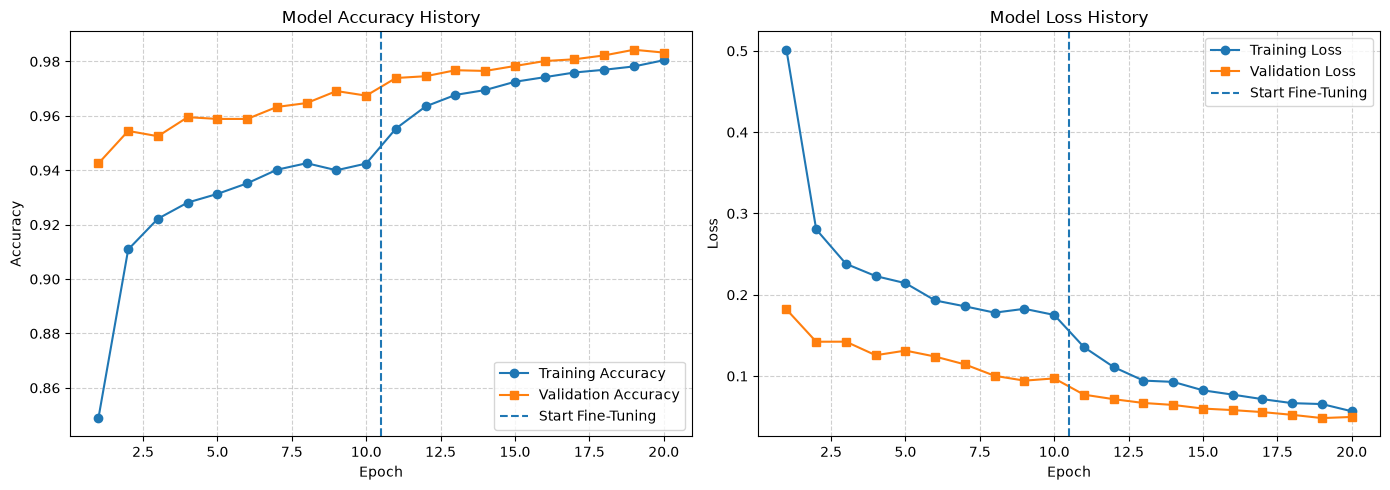

[SUCCESS] Training curves saved to:
../models/training_curves.png

LOADING BEST PHASE 2 MODEL
[INFO] Loading model from:
../models/best_phase2_model.keras
[SUCCESS] Best Phase 2 model loaded successfully.

VALIDATION DATASET EVALUATION
241/241 ━━━━━━━━━━━━━━━━━━━━ 41s 134ms/step - accuracy: 0.9843 - loss: 0.0483

[RESULT] Validation Loss: 0.0483
[RESULT] Validation Accuracy: 0.9843
[RESULT] Validation Accuracy (%): 98.43%

[INFO] Generating predictions...


W0000 00:00:1788085728.624926    8369 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


[INFO] Total validation samples: 7707

CLASSIFICATION REPORT
                                precision    recall  f1-score   support

              Apple_cedar_rust     1.0000    1.0000    1.0000        55
                 Apple_healthy     0.9763    1.0000    0.9880       329
                    Apple_scab     1.0000    0.9603    0.9798       126
    Bell_pepper_bacterial_spot     0.9950    1.0000    0.9975       200
           Bell_pepper_healthy     1.0000    1.0000    1.0000       295
             Blueberry_healthy     1.0000    1.0000    1.0000       300
                Cherry_healthy     1.0000    0.9941    0.9971       170
              Corn_common_rust     1.0000    0.9916    0.9958       239
           Corn_gray_leaf_spot     0.8723    0.7961    0.8325       103
     Corn_northern_leaf_blight     0.8942    0.9442    0.9185       197
               Grape_black_rot     1.0000    1.0000    1.0000       236
                 Grape_healthy     1.0000    1.0000    1.0000        84
  

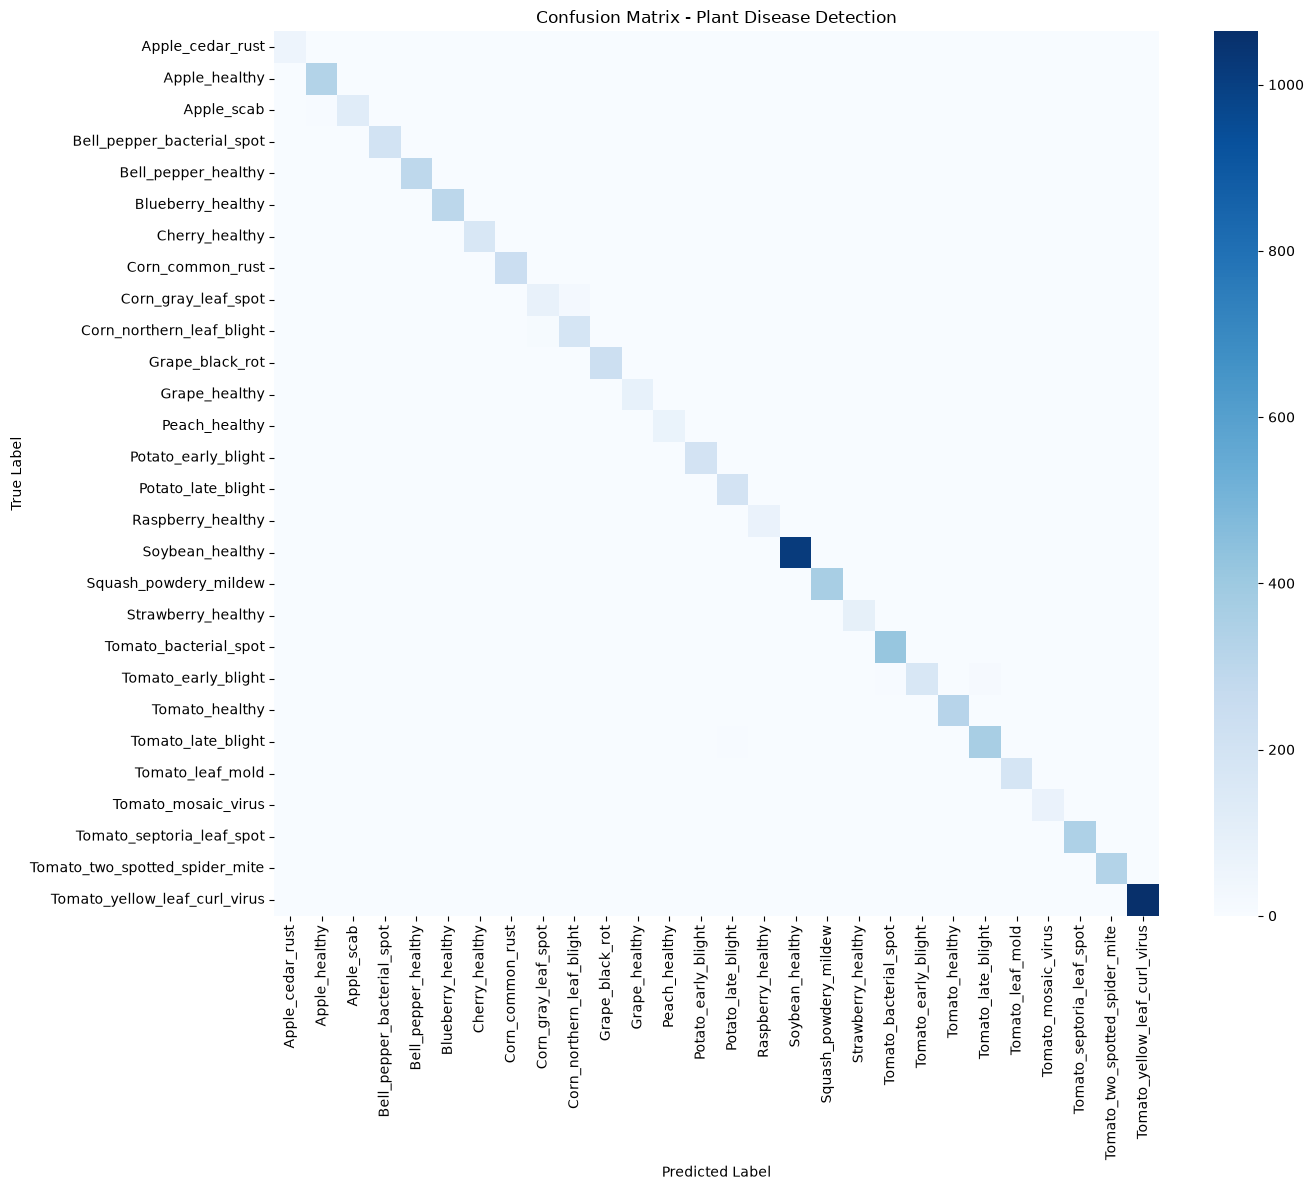

[SUCCESS] Confusion matrix saved to:
../models/confusion_matrix.png

EVALUATION COMPLETE
Best model: best_phase2_model.keras
Validation Accuracy: 98.43%
Classification Report:
../models/classification_report.txt
Confusion Matrix:
../models/confusion_matrix.png


In [22]:
# ============================================================
# TRAINING CURVES + VALIDATION EVALUATION
# ============================================================

print("=" * 60)
print("TRAINING VISUALIZATION & MODEL EVALUATION")
print("=" * 60)


# ============================================================
# 1. COMBINE PHASE 1 + PHASE 2 TRAINING HISTORY
# ============================================================

if "history_phase1" in locals():

    # -----------------------------
    # Phase 1 history
    # -----------------------------
    phase1_acc = history_phase1.history["accuracy"]
    phase1_val_acc = history_phase1.history["val_accuracy"]

    phase1_loss = history_phase1.history["loss"]
    phase1_val_loss = history_phase1.history["val_loss"]


    # -----------------------------
    # Phase 2 history
    # -----------------------------
    if "history_phase2" in locals():

        phase2_acc = history_phase2.history["accuracy"]
        phase2_val_acc = history_phase2.history["val_accuracy"]

        phase2_loss = history_phase2.history["loss"]
        phase2_val_loss = history_phase2.history["val_loss"]

    else:

        phase2_acc = []
        phase2_val_acc = []

        phase2_loss = []
        phase2_val_loss = []


    # -----------------------------
    # Combine histories
    # -----------------------------

    acc = phase1_acc + phase2_acc
    val_acc = phase1_val_acc + phase2_val_acc

    loss = phase1_loss + phase2_loss
    val_loss = phase1_val_loss + phase2_val_loss


    # Total number of epochs
    epochs_range = range(1, len(acc) + 1)

    # Number of Phase 1 epochs
    phase1_len = len(phase1_acc)


    print(f"[INFO] Phase 1 epochs: {phase1_len}")

    if "history_phase2" in locals():
        print(f"[INFO] Phase 2 epochs: {len(phase2_acc)}")

    print(f"[INFO] Total epochs: {len(acc)}")


    # ========================================================
    # 2. CREATE TRAINING CURVES
    # ========================================================

    plt.figure(figsize=(14, 5))


    # --------------------------------------------------------
    # Accuracy Plot
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    plt.plot(
        epochs_range,
        acc,
        label="Training Accuracy",
        marker="o"
    )

    plt.plot(
        epochs_range,
        val_acc,
        label="Validation Accuracy",
        marker="s"
    )

    # Mark beginning of Phase 2
    if "history_phase2" in locals():

        plt.axvline(
            x=phase1_len + 0.5,
            linestyle="--",
            label="Start Fine-Tuning"
        )

    plt.title("Model Accuracy History")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )

    plt.legend(
        loc="lower right"
    )


    # --------------------------------------------------------
    # Loss Plot
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    plt.plot(
        epochs_range,
        loss,
        label="Training Loss",
        marker="o"
    )

    plt.plot(
        epochs_range,
        val_loss,
        label="Validation Loss",
        marker="s"
    )

    # Mark beginning of Phase 2
    if "history_phase2" in locals():

        plt.axvline(
            x=phase1_len + 0.5,
            linestyle="--",
            label="Start Fine-Tuning"
        )

    plt.title("Model Loss History")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )

    plt.legend(
        loc="upper right"
    )


    # ========================================================
    # 3. SAVE TRAINING CURVES
    # ========================================================

    plt.tight_layout()

    plot_path = os.path.join(
        OUTPUT_DIR,
        "training_curves.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"[SUCCESS] Training curves saved to:\n"
        f"{plot_path}"
    )


else:

    print(
        "[WARNING] history_phase1 not found. "
        "Skipping training curves."
    )


# ============================================================
# 4. LOAD BEST PHASE 2 MODEL
# ============================================================

best_phase2_model_path = os.path.join(
    OUTPUT_DIR,
    "best_phase2_model.keras"
)

print("\n" + "=" * 60)
print("LOADING BEST PHASE 2 MODEL")
print("=" * 60)

print(
    f"[INFO] Loading model from:\n"
    f"{best_phase2_model_path}"
)


if os.path.exists(best_phase2_model_path):

    best_model = tf.keras.models.load_model(
        best_phase2_model_path
    )

    print(
        "[SUCCESS] Best Phase 2 model loaded successfully."
    )

else:

    raise FileNotFoundError(
        f"Best Phase 2 model not found:\n"
        f"{best_phase2_model_path}"
    )


# ============================================================
# 5. EVALUATE BEST PHASE 2 MODEL ON VALIDATION DATA
# ============================================================

if "val_ds" not in locals():

    raise RuntimeError(
        "val_ds is not available."
    )


print("\n" + "=" * 60)
print("VALIDATION DATASET EVALUATION")
print("=" * 60)


# ------------------------------------------------------------
# Evaluate using Keras
# ------------------------------------------------------------

val_loss_value, val_accuracy_value = best_model.evaluate(
    val_ds,
    verbose=1
)

print(
    f"\n[RESULT] Validation Loss: "
    f"{val_loss_value:.4f}"
)

print(
    f"[RESULT] Validation Accuracy: "
    f"{val_accuracy_value:.4f}"
)

print(
    f"[RESULT] Validation Accuracy (%): "
    f"{val_accuracy_value * 100:.2f}%"
)


# ============================================================
# 6. GENERATE TRUE LABELS AND PREDICTIONS
# ============================================================

print("\n[INFO] Generating predictions...")

y_true = []
y_pred = []


for images, labels in val_ds:

    # Model prediction
    predictions = best_model.predict(
        images,
        verbose=0
    )

    # Convert probabilities to class index
    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    # Store actual labels
    y_true.extend(
        labels.numpy()
    )

    # Store predictions
    y_pred.extend(
        predicted_classes
    )


# Convert to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)


print(
    f"[INFO] Total validation samples: "
    f"{len(y_true)}"
)


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)


report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)


# ------------------------------------------------------------
# Save classification report
# ------------------------------------------------------------

report_path = os.path.join(
    OUTPUT_DIR,
    "classification_report.txt"
)

with open(
    report_path,
    "w"
) as f:

    f.write(
        "Plant Disease Detection\n"
        "Validation Classification Report\n"
        "\n"
    )

    f.write(report)


print(
    f"[SUCCESS] Classification report saved to:\n"
    f"{report_path}"
)


# ============================================================
# 8. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)


cm = confusion_matrix(
    y_true,
    y_pred
)


# ------------------------------------------------------------
# Create confusion matrix plot
# ------------------------------------------------------------

plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    cm,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - Plant Disease Detection"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    rotation=90
)

plt.yticks(
    rotation=0
)

plt.tight_layout()


# ------------------------------------------------------------
# Save confusion matrix
# ------------------------------------------------------------

cm_path = os.path.join(
    OUTPUT_DIR,
    "confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    f"[SUCCESS] Confusion matrix saved to:\n"
    f"{cm_path}"
)


# ============================================================
# 9. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION COMPLETE")
print("=" * 60)

print(
    f"Best model: best_phase2_model.keras"
)

print(
    f"Validation Accuracy: "
    f"{val_accuracy_value * 100:.2f}%"
)

print(
    f"Classification Report:\n"
    f"{report_path}"
)

print(
    f"Confusion Matrix:\n"
    f"{cm_path}"
)

print("=" * 60)

##  Train on PlantDoc


In [3]:
import os
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix


OUTPUT_DIR = "../models"
MODEL_PATH = "../models/best_phase2_model.keras"
PLANTDOC_DIR = "../../PlantDoc"
PLANTDOC_TRAIN = os.path.join(PLANTDOC_DIR, "train")


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"PlantVillage model not found: {MODEL_PATH}")

if not os.path.exists(PLANTDOC_TRAIN):
    raise FileNotFoundError(f"PlantDoc train folder not found: {PLANTDOC_TRAIN}")

print("PlantVillage model:", MODEL_PATH)
print("PlantDoc train:", PLANTDOC_TRAIN)

train_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TRAIN,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TRAIN,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\nNumber of classes:", NUM_CLASSES)
print("Classes:")

for i, name in enumerate(class_names):
    print(i, name)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

PlantVillage model: ../models/best_phase2_model.keras
PlantDoc train: ../../PlantDoc/train
Found 2670 files belonging to 28 classes.
Using 2136 files for training.
Found 2670 files belonging to 28 classes.
Using 534 files for validation.

Number of classes: 28
Classes:
0 Apple_cedar_rust
1 Apple_healthy
2 Apple_scab
3 Bell_pepper_bacterial_spot
4 Bell_pepper_healthy
5 Blueberry_healthy
6 Cherry_healthy
7 Corn_common_rust
8 Corn_gray_leaf_spot
9 Corn_northern_leaf_blight
10 Grape_black_rot
11 Grape_healthy
12 Peach_healthy
13 Potato_early_blight
14 Potato_late_blight
15 Raspberry_healthy
16 Soybean_healthy
17 Squash_powdery_mildew
18 Strawberry_healthy
19 Tomato_bacterial_spot
20 Tomato_early_blight
21 Tomato_healthy
22 Tomato_late_blight
23 Tomato_leaf_mold
24 Tomato_mosaic_virus
25 Tomato_septoria_leaf_spot
26 Tomato_two_spotted_spider_mite
27 Tomato_yellow_leaf_curl_virus


In [4]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Loaded PlantVillage model successfully.")
model.summary()

print("Model output shape:", model.output_shape)

if model.output_shape[-1] != NUM_CLASSES:
    raise ValueError(
        f"Class mismatch: model has {model.output_shape[-1]} outputs "
        f"but PlantDoc has {NUM_CLASSES} classes."
    )

Loaded PlantVillage model successfully.


Model: "EfficientNetB0_PlantDisease"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_1 (Dropout)        │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense_1 (Dense)            │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout_2 (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head (Dense)     │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,140,249 (34.87 MB)

 Trainable params: 2,375,212 (9.06 MB)

 Non-trainable params: 2,014,611 (7.69 MB)

 Optimizer params: 4,750,426 (18.12 MB)

Model output shape: (None, 28)


##  Phase 1 Training - Feature Extraction
Train the top classification head while keeping base EfficientNetB0 weights frozen.

In [5]:
backbone = model.get_layer("efficientnetb0")

backbone.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

phase1_path = os.path.join(
    OUTPUT_DIR,
    "plantdoc_phase1_best.keras"
)

callbacks_phase1 = [
    tf.keras.callbacks.ModelCheckpoint(
        phase1_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_phase1
)

Epoch 1/10


/home/lenovo2004/plant_env/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788088958.998157    1546 cuda_dnn.cc:461] Loaded cuDNN version 92501


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.2551 - loss: 5.8842
Epoch 1: val_accuracy improved from None to 0.37079, saving model to ../models/plantdoc_phase1_best.keras

Epoch 1: finished saving model to ../models/plantdoc_phase1_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 45s 374ms/step - accuracy: 0.2551 - loss: 5.8842 - val_accuracy: 0.3708 - val_loss: 4.2344
Epoch 2/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.2879 - loss: 4.9607
Epoch 2: val_accuracy improved from 0.37079 to 0.42322, saving model to ../models/plantdoc_phase1_best.keras

Epoch 2: finished saving model to ../models/plantdoc_phase1_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - accuracy: 0.2879 - loss: 4.9607 - val_accuracy: 0.4232 - val_loss: 3.4061
Epoch 3/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.3052 - loss: 4.4131
Epoch 3: val_accuracy improved from 0.42322 to 0.42697, saving model to ../models/plantdoc_phase1_best.keras

Epoch 3: finished saving model to ../models/plan

W0000 00:00:1788089028.937451    2004 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 4: val_accuracy improved from 0.42697 to 0.43446, saving model to ../models/plantdoc_phase1_best.keras

Epoch 4: finished saving model to ../models/plantdoc_phase1_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 16s 237ms/step - accuracy: 0.3165 - loss: 3.9261 - val_accuracy: 0.4345 - val_loss: 2.8556
Epoch 5/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3497 - loss: 3.5551

...


Epoch 5: val_accuracy improved from 0.43446 to 0.43820, saving model to ../models/plantdoc_phase1_best.keras

Epoch 5: finished saving model to ../models/plantdoc_phase1_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - accuracy: 0.3497 - loss: 3.5551 - val_accuracy: 0.4382 - val_loss: 2.6901
Epoch 6/10


W0000 00:00:1788089048.948375    1764 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.3422 - loss: 3.4067
Epoch 6: val_accuracy improved from 0.43820 to 0.44757, saving model to ../models/plantdoc_phase1_best.keras

Epoch 6: finished saving model to ../models/plantdoc_phase1_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 307ms/step - accuracy: 0.3422 - loss: 3.4067 - val_accuracy: 0.4476 - val_loss: 2.5436
Epoch 7/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3675 - loss: 3.1104
Epoch 7: val_accuracy did not improve from 0.44757
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 203ms/step - accuracy: 0.3675 - loss: 3.1104 - val_accuracy: 0.4401 - val_loss: 2.4411
Epoch 8/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3666 - loss: 2.8808
Epoch 8: val_accuracy did not improve from 0.44757
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 203ms/step - accuracy: 0.3666 - loss: 2.8808 - val_accuracy: 0.4476 - val_loss: 2.3393
Epoch 9/10
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3769 - loss: 2.8004
Epoch 9: val_accuracy improved

W0000 00:00:1788089111.886579    1764 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.4026 - loss: 2.5558
Epoch 10: val_accuracy improved from 0.45131 to 0.46067, saving model to ../models/plantdoc_phase1_best.keras

Epoch 10: finished saving model to ../models/plantdoc_phase1_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.4026 - loss: 2.5558 - val_accuracy: 0.4607 - val_loss: 2.1369
Restoring model weights from the end of the best epoch: 10.


In [6]:
model = tf.keras.models.load_model(phase1_path)

backbone = model.get_layer("efficientnetb0")
backbone.trainable = True

for layer in backbone.layers[:-20]:
    layer.trainable = False

for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

phase2_path = os.path.join(
    OUTPUT_DIR,
    "plantdoc_finetuned_best.keras"
)

callbacks_phase2 = [
    tf.keras.callbacks.ModelCheckpoint(
        phase2_path,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_phase2
)

Epoch 1/15


E0000 00:00:1788089187.552139     789 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_PlantDisease_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
W0000 00:00:1788089189.953786    3085 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4190 - loss: 2.4514
Epoch 1: val_accuracy improved from None to 0.47378, saving model to ../models/plantdoc_finetuned_best.keras

Epoch 1: finished saving model to ../models/plantdoc_finetuned_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 308ms/step - accuracy: 0.4190 - loss: 2.4514 - val_accuracy: 0.4738 - val_loss: 2.0618
Epoch 2/15


W0000 00:00:1788089211.068409    3085 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.4251 - loss: 2.3690
Epoch 2: val_accuracy improved from 0.47378 to 0.48127, saving model to ../models/plantdoc_finetuned_best.keras

Epoch 2: finished saving model to ../models/plantdoc_finetuned_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 23s 348ms/step - accuracy: 0.4251 - loss: 2.3690 - val_accuracy: 0.4813 - val_loss: 2.0001
Epoch 3/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.4284 - loss: 2.3452
Epoch 3: val_accuracy improved from 0.48127 to 0.49438, saving model to ../models/plantdoc_finetuned_best.keras

Epoch 3: finished saving model to ../models/plantdoc_finetuned_best.keras
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 322ms/step - accuracy: 0.4284 - loss: 2.3452 - val_accuracy: 0.4944 - val_loss: 1.9515
Epoch 4/15
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4195 - loss: 2.3786
Epoch 4: val_accuracy did not improve from 0.49438
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.4195 - loss: 2.3786 - val_accuracy: 